# Accuracy-Size Tradeoff (LongBench qmsum and gov_report)
This notebook plots the "rouge-kept_attn" and the "rouge-kept_vrow" tradeoffs for long sequence length tasks that were ran. 
Top-k and Top-θ(cal.arcc) are expected to show a drop in the rouge score as the number of kept attention or the number of kept V-rows decreases. 

## Notebook usage: 

### Step 1 - prepare the results
run the experiments, which will produce the results in the following directories
1. the directory "products" to contain the per-run directories (each named with a unique timestamp) each containing the per-layer "kept_attn" csv.gz files
2. in the directory "results-Llama", for each of the timestamps there should an accuracy (rouge) result specified in one of the txt files 

### Step 2: 
To use this notebook, specify the list of runs' timestamps for which you would like to see the tradeoff plots under the `RESULTS_META_LIST` list



In [1]:
from data_util import ResultMeta, aggregate_accuracy_and_size_of_many_runs
from plot_util import plot_accuracy_vs_size

### LLaMA-3.1-8B-Instruct LongBench qmsum - first 20 test examples

In [ ]:
# Read a list of runs (each run is uniquely identified by a timestamp) and specify a label for each run as it should appear in the plot
RESULTS_META_LIST = [
    ResultMeta(timestamp='2025-04-08_17-55-27_902285', label='Baseline', k=999),
    ResultMeta(timestamp='2025-04-08_22-18-34_058364', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=32, ),
    ResultMeta(timestamp='2025-04-09_04-50-52_730314', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=64, ),
    ResultMeta(timestamp='2025-04-09_06-18-12_307294', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=128,),
    ResultMeta(timestamp='2025-04-09_00-05-58_346240', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=256,),
    ResultMeta(timestamp='2025-04-08_18-07-39_586687', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=512,),
    ResultMeta(timestamp='2025-04-08_22-40-36_974843', label='Top-θ(cal.arcc) post-softmax + vmc', k=32, ),
    ResultMeta(timestamp='2025-04-09_04-36-44_658306', label='Top-θ(cal.arcc) post-softmax + vmc', k=64, ),
    ResultMeta(timestamp='2025-04-09_05-23-21_303649', label='Top-θ(cal.arcc) post-softmax + vmc', k=128,),
    ResultMeta(timestamp='2025-04-09_00-50-00_962318', label='Top-θ(cal.arcc) post-softmax + vmc', k=256,),
    ResultMeta(timestamp='2025-04-08_17-57-30_718361', label='Top-θ(cal.arcc) post-softmax + vmc', k=512,),        
    ResultMeta(timestamp='2025-04-08_19-19-51_054384', label='Top-k pre-softmax + vmc + exact-sdc', k=32, ),
    ResultMeta(timestamp='2025-04-08_20-43-58_450806', label='Top-k pre-softmax + vmc + exact-sdc', k=64, ),
    ResultMeta(timestamp='2025-04-08_22-06-16_911015', label='Top-k pre-softmax + vmc + exact-sdc', k=128,),
    ResultMeta(timestamp='2025-04-08_23-26-40_079420', label='Top-k pre-softmax + vmc + exact-sdc', k=256,),
    ResultMeta(timestamp='2025-04-08_17-56-49_083146', label='Top-k pre-softmax + vmc + exact-sdc', k=512,),    
    ResultMeta(timestamp='2025-04-08_19-11-22_386940', label='Top-k post-softmax + vmc', k=32, ),
    ResultMeta(timestamp='2025-04-08_20-26-11_982190', label='Top-k post-softmax + vmc', k=64, ),
    ResultMeta(timestamp='2025-04-08_21-40-00_676946', label='Top-k post-softmax + vmc', k=128,),
    ResultMeta(timestamp='2025-04-08_22-51-33_875320', label='Top-k post-softmax + vmc', k=256,),
    ResultMeta(timestamp='2025-04-08_17-56-58_795235', label='Top-k post-softmax + vmc', k=512,),
]

# Read the list of results - for the generative_decoding phase - focusing on "kept_vrow" metric
RESULTS_DIR_PATH = "../results-Llama"
PRODUCTS_DIR_PATH = "../products"
INFERENCE_PHASE="generative_decoding"
ACCURACY_METRIC="rouge"
SIZE_METRIC="kept_vrow"

df_qmsum_generative_decoding = aggregate_accuracy_and_size_of_many_runs(RESULTS_META_LIST, ACCURACY_METRIC, SIZE_METRIC, INFERENCE_PHASE, RESULTS_DIR_PATH, PRODUCTS_DIR_PATH, num_cores=96)

Reading results in parallel using 96 parallel processes


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


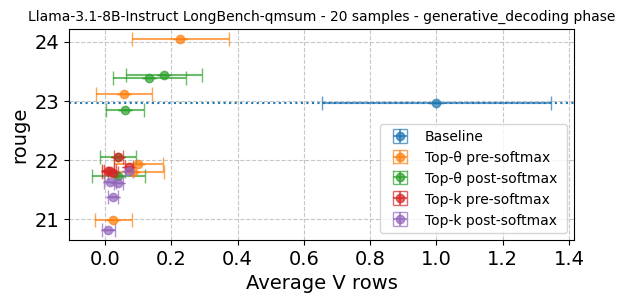

In [3]:
# plot tradeoff of rouge score as a function of used V rows during decoding - scatterplot with errorbars 
model_name = df_qmsum_generative_decoding.model_name.unique().item()
inference_phase = df_qmsum_generative_decoding.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-qmsum - 20 samples - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff"
plot_accuracy_vs_size(df_qmsum_generative_decoding, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=False,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average",# (across layers, GQA-groups, forward passes)",
                      plot_type='errorbar',
                      rcParams_override={'legend.fontsize':10},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


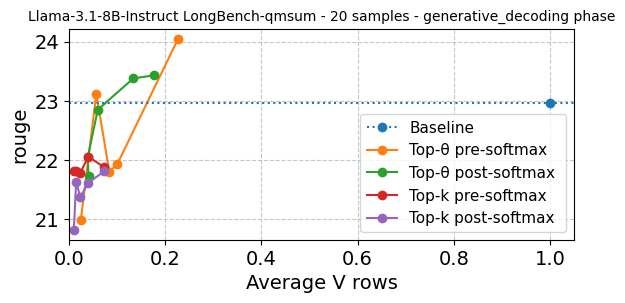

In [4]:
# plot tradeoff of rouge score as a function of used V rows during decoding - lineplots
model_name = df_qmsum_generative_decoding.model_name.unique().item()
inference_phase = df_qmsum_generative_decoding.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-qmsum - 20 samples - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff-lineplots"
plot_accuracy_vs_size(df_qmsum_generative_decoding, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=True,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average", # (across layers, GQA-groups, forward passes)",
                      plot_type='line',
                      rcParams_override={'legend.fontsize':11},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

In [5]:
# Re-read the list of results - this time for the prefill phase - focusing on "kept_attn" metric
RESULTS_DIR_PATH = "../results-Llama"
PRODUCTS_DIR_PATH = "../products"
INFERENCE_PHASE="prefill"
ACCURACY_METRIC="rouge"
SIZE_METRIC="kept_attn"

df_qmsum_prefill= aggregate_accuracy_and_size_of_many_runs(RESULTS_META_LIST, ACCURACY_METRIC, SIZE_METRIC, INFERENCE_PHASE, RESULTS_DIR_PATH, PRODUCTS_DIR_PATH, num_cores=96)

Reading results in parallel using 96 parallel processes


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


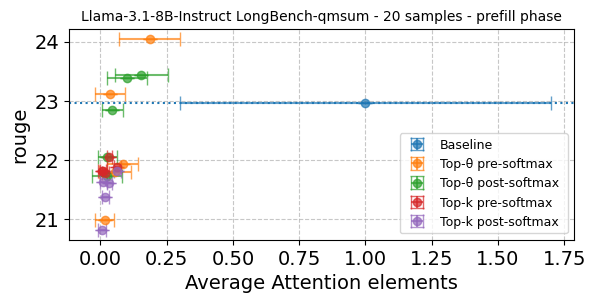

In [6]:
# plot prefill phase - scatterplots with errorbars
model_name = df_qmsum_prefill.model_name.unique().item()
inference_phase = df_qmsum_prefill.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-qmsum - 20 samples - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff"
plot_accuracy_vs_size(df_qmsum_prefill, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=False,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average", #"Average (across layers, heads, forward passes)",
                      plot_type="errorbar",
                      rcParams_override={'legend.fontsize':9},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


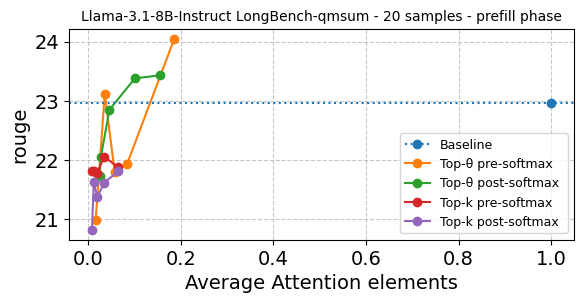

In [7]:
# plot prefill phase - scatterplots with errorbars
model_name = df_qmsum_prefill.model_name.unique().item()
inference_phase = df_qmsum_prefill.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-qmsum - 20 samples - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff-lineplots"
plot_accuracy_vs_size(df_qmsum_prefill, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=False,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average", #"Average (across layers, heads, forward passes)",
                      plot_type="line",
                      rcParams_override={'legend.fontsize':9},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

### LLaMA-3.1-8B-Instruct LongBench qmsum - full dataset (200 test examples)

In [90]:
# Read a list of runs (each run is uniquely identified by a timestamp) and specify a label for each run as it should appear in the plot
RESULTS_META_LIST = [
    ResultMeta(timestamp='2025-04-07_17-20-20_945838', label='Baseline', k=999),
    ResultMeta(timestamp='2025-04-23_11-57-33_398605', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=128,),
    ResultMeta(timestamp='2025-04-25_22-18-45_839441', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=256,),
    ResultMeta(timestamp='2025-04-27_19-48-14_444862', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=512,),
    ResultMeta(timestamp='2025-05-08_11-03-24_380731', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=756,), # uncomment and re-run - the new timestamp is correct already!
    ResultMeta(timestamp='2025-04-17_10-33-00_960122', label='Top-θ(cal.arcc) post-softmax + vmc', k=128,),
    ResultMeta(timestamp='2025-04-17_03-28-42_874509', label='Top-θ(cal.arcc) post-softmax + vmc', k=256,),
    ResultMeta(timestamp='2025-04-19_13-21-14_271615', label='Top-θ(cal.arcc) post-softmax + vmc', k=512,),        
    ResultMeta(timestamp='2025-05-08_11-03-31_414577', label='Top-θ(cal.arcc) post-softmax + vmc', k=756,), # uncomment and re-run - the new timestamp is correct already!
    ResultMeta(timestamp='2025-04-23_11-57-25_414582', label='Top-k pre-softmax + vmc + exact-sdc', k=128,),
    ResultMeta(timestamp='2025-04-23_20-30-24_263274', label='Top-k pre-softmax + vmc + exact-sdc', k=256,),
    ResultMeta(timestamp='2025-04-24_05-01-46_863303', label='Top-k pre-softmax + vmc + exact-sdc', k=512,),    
    ResultMeta(timestamp='2025-04-24_13-31-42_308075', label='Top-k pre-softmax + vmc + exact-sdc', k=756,),    
    ResultMeta(timestamp='2025-04-14_16-40-59_439496', label='Top-k post-softmax + vmc', k=128,),
    ResultMeta(timestamp='2025-04-15_05-08-13_701010', label='Top-k post-softmax + vmc', k=256,),
    ResultMeta(timestamp='2025-04-16_08-43-59_678169', label='Top-k post-softmax + vmc', k=512,),
    ResultMeta(timestamp='2025-04-16_15-55-41_567261', label='Top-k post-softmax + vmc', k=756,),
]

# Read the list of results - for the generative_decoding phase - focusing on "kept_vrow" metric
RESULTS_DIR_PATH = "../results-Llama"
PRODUCTS_DIR_PATH = "../products"
INFERENCE_PHASE="generative_decoding"
ACCURACY_METRIC="rouge"
SIZE_METRIC="kept_vrow"

df_qmsum_generative_decoding = aggregate_accuracy_and_size_of_many_runs(RESULTS_META_LIST, ACCURACY_METRIC, SIZE_METRIC, INFERENCE_PHASE, RESULTS_DIR_PATH, PRODUCTS_DIR_PATH, num_cores=192)

Reading results in parallel using 192 parallel processes


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


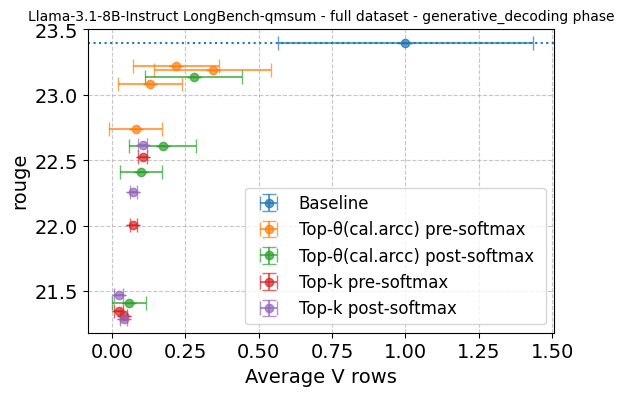

In [91]:
# plot tradeoff of rouge score as a function of used V rows during decoding - scatterplot with errorbars 
model_name = df_qmsum_generative_decoding.model_name.unique().item()
inference_phase = df_qmsum_generative_decoding.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-qmsum - full dataset - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff"
plot_accuracy_vs_size(df_qmsum_generative_decoding, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=False,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average",# (across layers, GQA-groups, forward passes)",
                      plot_type='errorbar',
                      rcParams_override={'legend.fontsize':12, 'figure.figsize' : [6, 4],},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


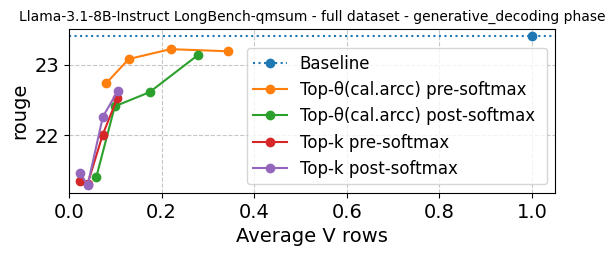

In [92]:
# plot tradeoff of rouge score as a function of used V rows during decoding - lineplots
model_name = df_qmsum_generative_decoding.model_name.unique().item()
inference_phase = df_qmsum_generative_decoding.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-qmsum - full dataset - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff-lineplots"
plot_accuracy_vs_size(df_qmsum_generative_decoding, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=True,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average", # (across layers, GQA-groups, forward passes)",
                      plot_type='line',
                      rcParams_override={'legend.fontsize':12, 'legend.loc':'lower right','figure.figsize' : [6, 2.6],},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

In [93]:
# Re-read the list of results - this time for the prefill phase - focusing on "kept_attn" metric
RESULTS_DIR_PATH = "../results-Llama"
PRODUCTS_DIR_PATH = "../products"
INFERENCE_PHASE="prefill"
ACCURACY_METRIC="rouge"
SIZE_METRIC="kept_attn"

df_qmsum_prefill = aggregate_accuracy_and_size_of_many_runs(RESULTS_META_LIST, ACCURACY_METRIC, SIZE_METRIC, INFERENCE_PHASE, RESULTS_DIR_PATH, PRODUCTS_DIR_PATH, num_cores=192)

Reading results in parallel using 192 parallel processes


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


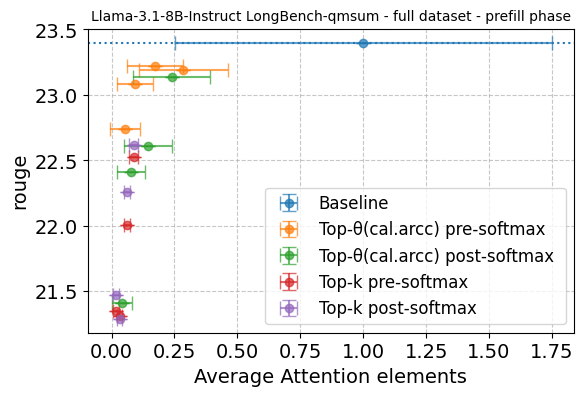

In [94]:
# plot prefill phase - scatterplots with errorbars
model_name = df_qmsum_prefill.model_name.unique().item()
inference_phase = df_qmsum_prefill.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-qmsum - full dataset - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff"
plot_accuracy_vs_size(df_qmsum_prefill, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=False,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average", #"Average (across layers, heads, forward passes)",
                      plot_type="errorbar",
                      rcParams_override={'legend.fontsize':12, 'figure.figsize' : [6, 4],},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


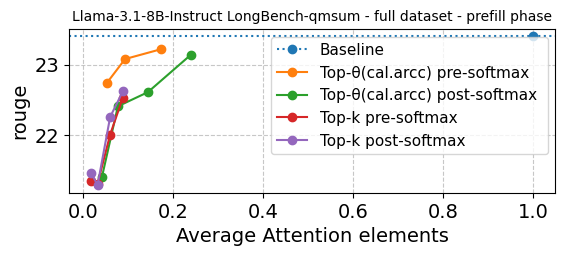

In [84]:
# plot prefill phase - scatterplots with errorbars
model_name = df_qmsum_prefill.model_name.unique().item()
inference_phase = df_qmsum_prefill.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-qmsum - full dataset - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff-lineplots"
plot_accuracy_vs_size(df_qmsum_prefill, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=False,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average", #"Average (across layers, heads, forward passes)",
                      plot_type="line",
                      rcParams_override={'legend.fontsize':11, 'figure.figsize' : [6, 2.6],},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

### LLaMA-3.1-8B-Instruct LongBench gov_report - full dataset (200 test examples)

In [59]:
# Read a list of runs (each run is uniquely identified by a timestamp) and specify a label for each run as it should appear in the plot
RESULTS_META_LIST = [
    ResultMeta(timestamp='2025-04-09_17-34-28_654317', label='Baseline', k=999),
    ResultMeta(timestamp='2025-04-26_10-02-41_711830', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=128,),
    ResultMeta(timestamp='2025-04-27_23-39-45_403838', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=256,),
    ResultMeta(timestamp='2025-04-29_09-44-46_499998', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=512,),
    ResultMeta(timestamp='2025-05-08_11-02-58_682523', label='Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc', k=756,),
    ResultMeta(timestamp='2025-04-23_11-57-49_835361', label='Top-θ(cal.arcc) post-softmax + vmc', k=128,),
    ResultMeta(timestamp='2025-04-25_01-15-41_415189', label='Top-θ(cal.arcc) post-softmax + vmc', k=256,),
    ResultMeta(timestamp='2025-05-05_16-48-36_495207', label='Top-θ(cal.arcc) post-softmax + vmc', k=512,),        
    ResultMeta(timestamp='2025-05-08_11-03-07_591731', label='Top-θ(cal.arcc) post-softmax + vmc', k=756,),
    ResultMeta(timestamp='2025-04-25_23-37-27_424025', label='Top-k pre-softmax + vmc + exact-sdc', k=128,),
    ResultMeta(timestamp='2025-04-26_05-56-36_651144', label='Top-k pre-softmax + vmc + exact-sdc', k=256,),
    ResultMeta(timestamp='2025-04-26_12-16-18_462819', label='Top-k pre-softmax + vmc + exact-sdc', k=512,),    
    ResultMeta(timestamp='2025-04-26_18-36-50_566293', label='Top-k pre-softmax + vmc + exact-sdc', k=756,),    
    ResultMeta(timestamp='2025-04-14_11-32-41_162279', label='Top-k post-softmax + vmc', k=128,),
    ResultMeta(timestamp='2025-04-10_10-00-05_802004', label='Top-k post-softmax + vmc', k=256,),
    ResultMeta(timestamp='2025-04-10_19-40-45_884053', label='Top-k post-softmax + vmc', k=512,),
    ResultMeta(timestamp='2025-04-11_05-18-48_838271', label='Top-k post-softmax + vmc', k=756,),
]

# Read the list of results - for the generative_decoding phase - focusing on "kept_vrow" metric
RESULTS_DIR_PATH = "../results-Llama"
PRODUCTS_DIR_PATH = "../products"
INFERENCE_PHASE="generative_decoding"
ACCURACY_METRIC="rouge"
SIZE_METRIC="kept_vrow"

df_gov_report_generative_decoding = aggregate_accuracy_and_size_of_many_runs(RESULTS_META_LIST, ACCURACY_METRIC, SIZE_METRIC, INFERENCE_PHASE, RESULTS_DIR_PATH, PRODUCTS_DIR_PATH, num_cores=192)

Reading results in parallel using 192 parallel processes


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


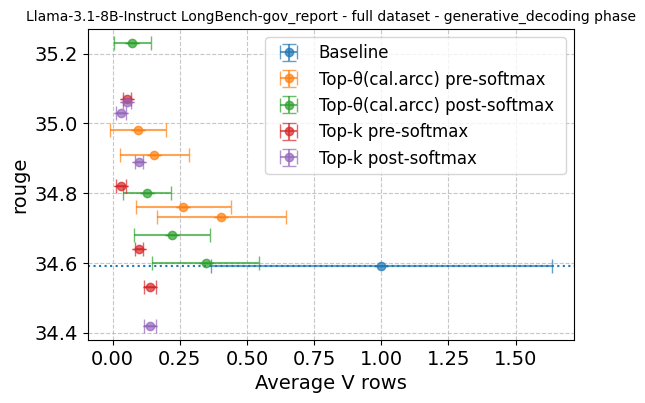

In [60]:
# plot tradeoff of rouge score as a function of used V rows during decoding - scatterplot with errorbars 
model_name = df_gov_report_generative_decoding.model_name.unique().item()
inference_phase = df_gov_report_generative_decoding.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-gov_report - full dataset - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff"
plot_accuracy_vs_size(df_gov_report_generative_decoding, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=False,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average",# (across layers, GQA-groups, forward passes)",
                      plot_type='errorbar',
                      rcParams_override={'legend.fontsize':12, 'figure.figsize' : [6, 4],},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


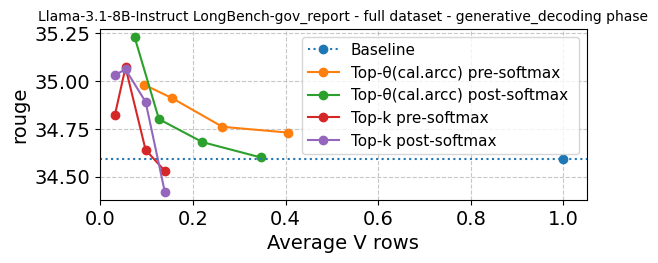

In [68]:
# plot tradeoff of rouge score as a function of used V rows during decoding - lineplots
model_name = df_gov_report_generative_decoding.model_name.unique().item()
inference_phase = df_gov_report_generative_decoding.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-gov_report - full dataset - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff-lineplots"
plot_accuracy_vs_size(df_gov_report_generative_decoding, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=True,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average", # (across layers, GQA-groups, forward passes)",
                      plot_type='line',
                      rcParams_override={'legend.fontsize':11, 'figure.figsize' : [6, 2.6],},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

In [62]:
# Re-read the list of results - this time for the prefill phase - focusing on "kept_attn" metric
RESULTS_DIR_PATH = "../results-Llama"
PRODUCTS_DIR_PATH = "../products"
INFERENCE_PHASE="prefill"
ACCURACY_METRIC="rouge"
SIZE_METRIC="kept_attn"

df_gov_report_prefill = aggregate_accuracy_and_size_of_many_runs(RESULTS_META_LIST, ACCURACY_METRIC, SIZE_METRIC, INFERENCE_PHASE, RESULTS_DIR_PATH, PRODUCTS_DIR_PATH, num_cores=192)

Reading results in parallel using 192 parallel processes


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


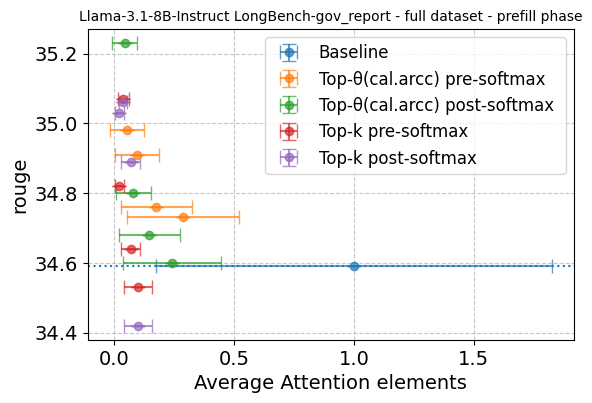

In [63]:
# plot prefill phase - scatterplots with errorbars
model_name = df_gov_report_prefill.model_name.unique().item()
inference_phase = df_gov_report_prefill.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-gov_report - full dataset - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff"
plot_accuracy_vs_size(df_gov_report_prefill, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=False,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average", #"Average (across layers, heads, forward passes)",
                      plot_type="errorbar",
                      rcParams_override={'legend.fontsize':12, 'figure.figsize' : [6, 4],},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


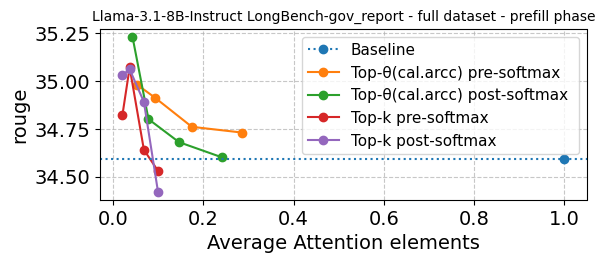

In [69]:
# plot prefill phase - scatterplots with errorbars
model_name = df_gov_report_prefill.model_name.unique().item()
inference_phase = df_gov_report_prefill.inference_phase.unique().item()
TITLE = f'{model_name} LongBench-gov_report - full dataset - {inference_phase} phase'
OUTPUT_DIR_PATH = "../figures/accuracy-kept_attn-kept_vrow-tradeoff-lineplots"
plot_accuracy_vs_size(df_gov_report_prefill, 
                      TITLE, 
                      OUTPUT_DIR_PATH, 
                      full_xlim=False,
                      full_ylim=False,
                      normalize_size_by_fullsize=True,
                      x_label_prefix="Average", #"Average (across layers, heads, forward passes)",
                      plot_type="line",
                      rcParams_override={'legend.fontsize':11, 'figure.figsize' : [6, 2.6],},
                      concise_labels=True,
                      add_horizontal_line_for_label=['Baseline'],
                      yaxis_disable_percentage=True)

In [65]:
df_gov_report_generative_decoding

,timestamp,label,k,model_name,accuracy_mean,accuracy_std,kv_seq_len_mean,kv_seq_len_std,size_mean,size_std,fullsize_mean,fullsize_std,inference_phase,accuracy_metric,size_metric
0,2025-04-09_17-34-28_654317,Baseline,999,Llama-3.1-8B-Instruct,34.59,0,10532.675134,6690.652223,10532.675134,6690.652223,10532.675134,6690.652223,generative_decoding,rouge,kept_vrow
1,2025-04-26_10-02-41_711830,Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc,128,Llama-3.1-8B-Instruct,34.98,0,10531.405000,6689.491775,996.323518,1104.148542,10531.405000,6689.491775,generative_decoding,rouge,kept_vrow
2,2025-04-27_23-39-45_403838,Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc,256,Llama-3.1-8B-Instruct,34.91,0,10531.405000,6689.491775,1631.203540,1347.818775,10531.405000,6689.491775,generative_decoding,rouge,kept_vrow
3,2025-04-29_09-44-46_499998,Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc,512,Llama-3.1-8B-Instruct,34.76,0,10531.405000,6689.491775,2777.972507,1868.683267,10531.405000,6689.491775,generative_decoding,rouge,kept_vrow
4,2025-05-08_11-02-58_682523,Top-θ(cal.arcc) pre-softmax + vmc + exact-sdc,756,Llama-3.1-8B-Instruct,34.73,0,10532.282234,6691.529650,4267.040099,2528.763955,10532.282234,6691.529650,generative_decoding,rouge,kept_vrow
5,2025-04-23_11-57-49_835361,Top-θ(cal.arcc) post-softmax + vmc,128,Llama-3.1-8B-Instruct,35.23,0,10532.029274,6690.338431,778.693005,725.651992,10532.029274,6690.338431,generative_decoding,rouge,kept_vrow
6,2025-04-25_01-15-41_415189,Top-θ(cal.arcc) post-softmax + vmc,256,Llama-3.1-8B-Instruct,34.80,0,10531.405000,6689.491775,1334.158113,944.203592,10531.405000,6689.491775,generative_decoding,rouge,kept_vrow
7,2025-05-05_16-48-36_495207,Top-θ(cal.arcc) post-softmax + vmc,512,Llama-3.1-8B-Instruct,34.68,0,10531.405000,6689.491775,2324.627790,1479.241494,10531.405000,6689.491775,generative_decoding,rouge,kept_vrow
8,2025-05-08_11-03-07_591731,Top-θ(cal.arcc) post-softmax + vmc,756,Llama-3.1-8B-Instruct,34.60,0,10531.405000,6689.491775,3654.140659,2097.302358,10531.405000,6689.491775,generative_decoding,rouge,kept_vrow
9,2025-04-25_23-37-27_424025,Top-k pre-softmax + vmc + exact-sdc,128,Llama-3.1-8B-Instruct,34.82,0,10531.405000,6689.491775,330.632493,204.224840,10531.405000,6689.491775,generative_decoding,rouge,kept_vrow
